# Reinforcement learning

This notebook trains a small deep Q network to operate the two basins in
scenario theta, and measures it against leaving the network uncontrolled.

Theta is a good place to start: two depths in, two valve settings out, and a
full simulation runs in a fraction of a second, so an agent can see hundreds of
episodes without a GPU.

In [ ]:
!pip install torch pystorms

In [2]:
import random
from collections import namedtuple, deque

import numpy as np
import torch
import matplotlib.pyplot as plt
import pystorms

plt.rcParams.update({"font.size": 14})
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Replay memory

Transitions are stored and sampled out of order, so consecutive, highly
correlated steps do not dominate a gradient update.

In [3]:
class ReplayMemory:
    """Fixed size container of state transitions, sampled uniformly."""

    def __init__(self, capacity=10000,
                 columns=("state", "action", "next_state", "reward")):
        self.memory = deque([], maxlen=capacity)
        self.container = namedtuple("Transition", columns)

    def push(self, *args):
        self.memory.append(self.container(*args))

    def sample(self, batch_size=64):
        return self.container(*zip(*random.sample(self.memory, batch_size)))

    def __len__(self):
        return len(self.memory)

## The network

A plain feed forward network mapping the two basin depths to one value per
candidate action. Registering the layers in a `Sequential` matters: a bare
Python list would keep the parameters invisible to the optimizer.

In [4]:
class AgentSmith(torch.nn.Module):
    """Feed forward Q network."""

    def __init__(self, n_states, n_actions, hidden=64):
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(n_states, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.network(x)

## Discretizing the valves

Deep Q learning picks from a finite set, so we take three positions per orifice
and enumerate the nine combinations.

In [5]:
SETTINGS = [0.0, 0.5, 1.0]
ACTIONS = np.array([[a, b] for a in SETTINGS for b in SETTINGS], dtype=float)

# act every CONTROL_INTERVAL simulation steps rather than every step
CONTROL_INTERVAL = 100

print(f"{len(ACTIONS)} candidate actions")

9 candidate actions


## Running one episode

The scenario logs a performance penalty every step. The reward for a decision
is the negative of the penalty accumulated since the previous decision, so the
agent is rewarded for keeping outflow under the threshold and out of flooding.

Building a fresh scenario once per episode inside a single Python process needs
pystorms 2.0 or newer.

In [6]:
def run_episode(policy, memory=None):
    """Play one episode. `policy` maps a state to an index into ACTIONS."""
    env = pystorms.scenarios.theta()

    state = env.state()
    penalty_seen = 0.0
    action_idx = policy(state)
    steps = 0
    done = False

    while not done:
        done = env.step(ACTIONS[action_idx])
        steps += 1

        if steps % CONTROL_INTERVAL == 0 or done:
            total = sum(env.data_log["performance_measure"])
            reward = -(total - penalty_seen) / CONTROL_INTERVAL
            penalty_seen = total

            next_state = None if done else env.state()
            if memory is not None:
                memory.push(state, action_idx, next_state, reward)

            if not done:
                state = next_state
                action_idx = policy(state)

    return env.performance()

## Baseline

What does the network do if nobody touches it?

In [7]:
uncontrolled = run_episode(lambda s: len(ACTIONS) - 1)  # both valves fully open
print(f"uncontrolled performance: {uncontrolled:.1f}")

uncontrolled performance: 1630.3


## Training

Standard DQN: an online network chooses actions, a target network supplies the
bootstrap value and is refreshed periodically, and exploration decays from
almost always random to almost always greedy.

In [8]:
policy_net = AgentSmith(2, len(ACTIONS))
target_net = AgentSmith(2, len(ACTIONS))
target_net.load_state_dict(policy_net.state_dict())

optimizer = torch.optim.Adam(policy_net.parameters(), lr=1e-3)
memory = ReplayMemory(capacity=20000)

BATCH_SIZE = 64
GAMMA = 0.99
EPISODES = 40
TARGET_UPDATE = 5

epsilon = 1.0


def greedy(state):
    with torch.no_grad():
        q = policy_net(torch.tensor(state, dtype=torch.float32))
    return int(q.argmax())


def explore(state):
    if random.random() < epsilon:
        return random.randrange(len(ACTIONS))
    return greedy(state)


def optimize():
    if len(memory) < BATCH_SIZE:
        return
    batch = memory.sample(BATCH_SIZE)

    states = torch.tensor(np.asarray(batch.state), dtype=torch.float32)
    actions = torch.tensor(batch.action, dtype=torch.int64).unsqueeze(1)
    rewards = torch.tensor(batch.reward, dtype=torch.float32)

    q = policy_net(states).gather(1, actions).squeeze(1)

    nonfinal = torch.tensor([s is not None for s in batch.next_state],
                            dtype=torch.bool)
    next_values = torch.zeros(BATCH_SIZE)
    if nonfinal.any():
        nxt = torch.tensor(
            np.asarray([s for s in batch.next_state if s is not None]),
            dtype=torch.float32,
        )
        with torch.no_grad():
            next_values[nonfinal] = target_net(nxt).max(1).values

    expected = rewards + GAMMA * next_values
    loss = torch.nn.functional.smooth_l1_loss(q, expected)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()


history = []
for episode in range(EPISODES):
    epsilon = max(0.05, 1.0 - episode / (0.7 * EPISODES))
    performance = run_episode(explore, memory)

    for _ in range(20):
        optimize()

    if episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    history.append(performance)
    if episode % 5 == 0:
        print(f"episode {episode:3d}  epsilon {epsilon:.2f}  performance {performance:9.1f}")

episode   0  epsilon 1.00  performance    6893.4


episode   5  epsilon 0.82  performance 256010159.4


episode  10  epsilon 0.64  performance 140006298.2


episode  15  epsilon 0.46  performance 25010371.9


episode  20  epsilon 0.29  performance 446007388.9


episode  25  epsilon 0.11  performance 1373003276.7


episode  30  epsilon 0.05  performance    1893.7


episode  35  epsilon 0.05  performance    1625.9


## Did it learn anything?

In [9]:
trained = run_episode(greedy)

print(f"uncontrolled     : {uncontrolled:.1f}")
print(f"trained (greedy) : {trained:.1f}")
print(f"best in training : {min(history):.1f}")

uncontrolled     : 1630.3
trained (greedy) : 1625.4
best in training : 1605.6


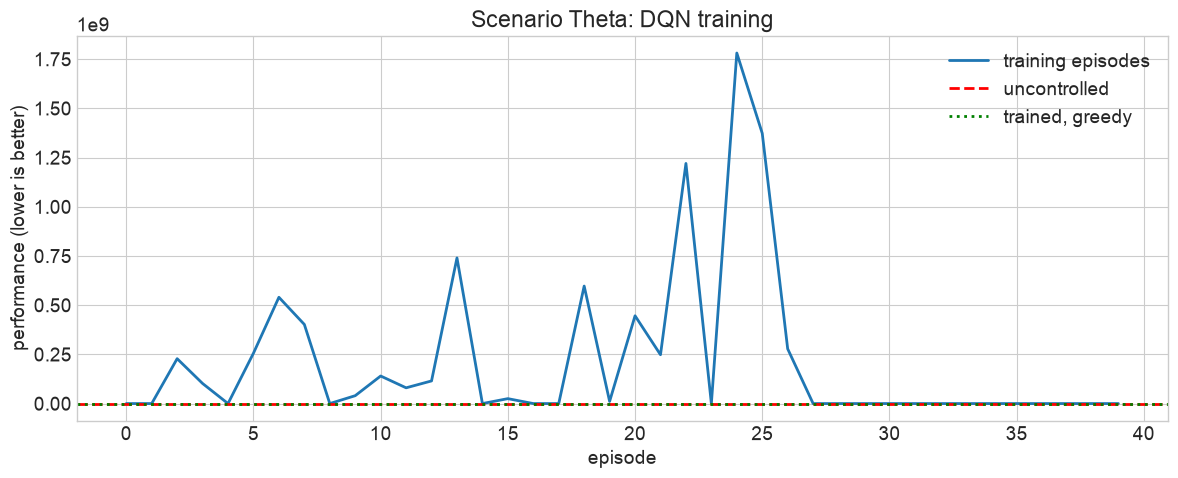

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history, linewidth=2.0, label="training episodes")
ax.axhline(uncontrolled, color="red", linestyle="--", linewidth=2.0,
           label="uncontrolled")
ax.axhline(trained, color="green", linestyle=":", linewidth=2.0,
           label="trained, greedy")
ax.set_xlabel("episode")
ax.set_ylabel("performance (lower is better)")
ax.set_title("Scenario Theta: DQN training")
ax.legend()
plt.tight_layout()

Forty episodes of a small network is a demonstration, not a tuned result;
the curve is noisy and a rule based controller on the same scenario is hard to
beat. `RuleBasedControl.ipynb` has one to compare against.

## Exercises

1. The reward divides the accumulated penalty by `CONTROL_INTERVAL`. Try
   shaping it differently, for example penalizing flooding separately from
   threshold exceedance, and see what the agent learns instead.
2. Give the agent more to look at. Feeding it the previous action or a short
   history of depths turns a memoryless policy into something closer to a
   controller with state.
3. Train against `pystorms.scenarios.theta(level="2")`, where depth readings
   are noisy and valves stick, and compare with the agent trained on the clean
   scenario.